In [1]:
import pandas as pd
import numpy as np
import requests
import data_collection_us as dcu
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
teams_url = 'https://statsapi.mlb.com/api/v1/teams?sportId=1'
teams_data = requests.get(teams_url).json()
print(teams_data.keys())

In [ ]:
for team in teams_data['teams']:
    print(team['id'], team['name'])

In [ ]:
team_id = 136
roster_url = f'https://statsapi.mlb.com/api/v1/teams/{team_id}/roster?rosterType=active&date=2025-04-01'
roster_data = requests.get(roster_url).json()
print(len(roster_data['roster']))
for person in roster_data['roster']:
    print(person)


In [ ]:
julio_stats = requests.get('https://statsapi.mlb.com/api/v1/people/641487/stats?stats=byDateRange&group=hitting&startDate=2021-04-01&endDate=2023-04-01').json()
julio_stats['stats'][0]['splits']

In [2]:
training_2019 = dcu.get_training_data(2019)

In [7]:
training_2019.columns.tolist()

['id',
 'team',
 'year',
 'gamesPlayed',
 'gamesStarted',
 'flyOuts',
 'groundOuts',
 'airOuts',
 'runs',
 'doubles',
 'triples',
 'homeRuns',
 'strikeOuts',
 'baseOnBalls',
 'intentionalWalks',
 'hits',
 'hitByPitch',
 'avg',
 'atBats',
 'obp',
 'slg',
 'ops',
 'caughtStealing',
 'stolenBases',
 'stolenBasePercentage',
 'caughtStealingPercentage',
 'groundIntoDoublePlay',
 'numberOfPitches',
 'era',
 'inningsPitched',
 'wins',
 'losses',
 'saves',
 'saveOpportunities',
 'holds',
 'blownSaves',
 'earnedRuns',
 'whip',
 'battersFaced',
 'outs',
 'gamesPitched',
 'completeGames',
 'shutouts',
 'strikes',
 'strikePercentage',
 'hitBatsmen',
 'balks',
 'wildPitches',
 'pickoffs',
 'totalBases',
 'groundOutsToAirouts',
 'winPercentage',
 'pitchesPerInning',
 'gamesFinished',
 'strikeoutWalkRatio',
 'strikeoutsPer9Inn',
 'walksPer9Inn',
 'hitsPer9Inn',
 'runsScoredPer9',
 'homeRunsPer9',
 'inheritedRunners',
 'inheritedRunnersScored',
 'catchersInterference',
 'sacBunts',
 'sacFlies',
 'grou

In [20]:
training_2019['ops'] = pd.to_numeric(training_2019['ops'])
#training_2019['strikeoutsPer9Inn'] = pd.to_numeric(training_2019['strikeoutsPer9Inn'])

In [21]:
summary = training_2019[['strikeOuts', 'ops', 'stolenBases', 'era', 'strikeoutsPer9Inn', 'whip']].describe()
summary

,strikeOuts,ops,stolenBases
count,746.000000,746.000000,746.000000
mean,112.977212,0.720497,7.284182
std,100.693919,0.204585,11.016142
min,0.000000,0.000000,0.000000
25%,28.250000,0.649250,1.000000
50%,94.500000,0.727500,3.000000
75%,166.750000,0.794750,9.000000
max,580.000000,2.000000,93.000000


In [4]:
from matplotlib.ticker import MaxNLocator

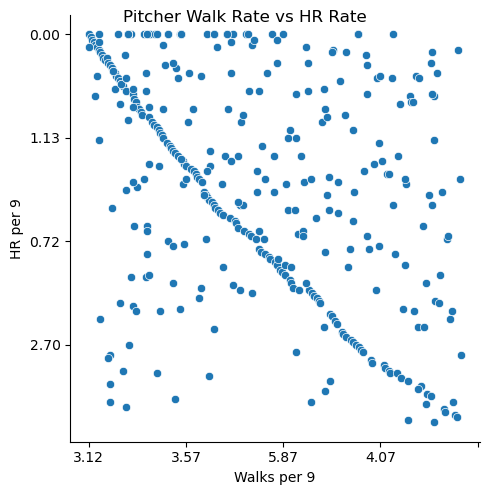

In [5]:
fig1 = sns.relplot(data=training_2019, x='walksPer9Inn', y='homeRunsPer9')

for ax in fig1.axes.flat:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
fig1.set_axis_labels("Walks per 9", "HR per 9")
fig1.figure.suptitle("Pitcher Walk Rate vs HR Rate")
fig1.savefig('pitcher_visual.png')

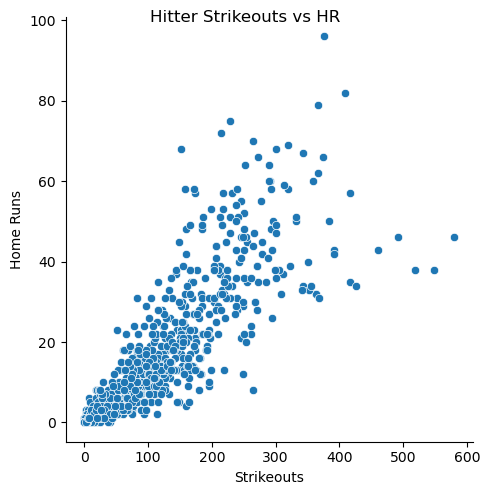

In [6]:
fig2 = sns.relplot(data=training_2019, x='strikeOuts', y='homeRuns')
fig2.set_axis_labels("Strikeouts", "Home Runs")
fig2.figure.suptitle("Hitter Strikeouts vs HR")
fig2.savefig('hitter_visual.png')